In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import numpy as np

In [37]:


df = pd.read_csv('Research Data - Summary.csv')

# Function to extract mean and std from strings like "0.7746 (±0.0129)"
def extract_mean_std(value):
    if pd.isna(value) or isinstance(value, float):
        return value, 0
    match = re.match(r"([\d.]+)\s*\(±([\d.]+)\)", str(value))
    if match:
        return float(match.group(1)), float(match.group(2))
    return float(value), 0

# Apply extraction to relevant columns
for col in ['Accuracy_Fixed_Testing', 'F1_Fixed_Testing', 'Epochs_Fixed_Testing']:
    df[[f'{col}_mean', f'{col}_std']] = df[col].apply(
        lambda x: pd.Series(extract_mean_std(x))
    )

# Convert categorical columns to appropriate types
df['Base_Model_Class'] = pd.to_numeric(df['Base_Model_Class'], errors='coerce')
df['FT/Direct_Classes'] = pd.to_numeric(df['FT/Direct_Classes'], errors='coerce')
df['FT/T_Instance_per_class'] = pd.to_numeric(df['FT/T_Instance_per_class'], errors='coerce')

In [38]:
df

,Model,Accuracy,Accuracy_Fixed_Testing,F1,F1_Fixed_Testing,Epochs,Epochs_Fixed_Testing,Base_Model_Class,FT/Direct_Classes,FT/T_Instance_per_class,Model_Type,Overlapping,Accuracy_Fixed_Testing_mean,Accuracy_Fixed_Testing_std,F1_Fixed_Testing_mean,F1_Fixed_Testing_std,Epochs_Fixed_Testing_mean,Epochs_Fixed_Testing_std
0,240 Class ISL Base Model,0.6079,0.6079,NaN,NaN,NaN,NaN,240.0,NaN,NaN,BASE,No,0.6079,0.0000,NaN,0.0000,NaN,0.0000
1,200 Class ISL Base Model,0.6247,0.6247,NaN,NaN,NaN,NaN,200.0,NaN,NaN,BASE,No,0.6247,0.0000,NaN,0.0000,NaN,0.0000
2,160 Class ISL Base Model,0.6478,0.6478,NaN,NaN,NaN,NaN,160.0,NaN,NaN,BASE,No,0.6478,0.0000,NaN,0.0000,NaN,0.0000
3,120 Class ISL Base Model,0.6173,0.6173,NaN,NaN,NaN,NaN,120.0,NaN,NaN,BASE,No,0.6173,0.0000,NaN,0.0000,NaN,0.0000
4,80 Class ISL Base Model,0.6468,0.6468,NaN,NaN,NaN,NaN,80.0,NaN,NaN,BASE,No,0.6468,0.0000,NaN,0.0000,NaN,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,64 Class SSL- 2 Instance Per Class (5 runs avg),0.3160 (±0.0494),0.3241 (±0.0405),0.2937 (±0.0511),0.3166 (±0.0405),120.0000 (±17.8885),168.2000 (±21.8211),NaN,64.0,2.0,DIRECT,NaN,0.3241,0.0405,0.3166,0.0405,168.2,21.8211
67,48 Class SSL- 6 Instance Per Class (5 runs avg),0.7708 (±0.0275),0.7970 (±0.0167),0.7665 (±0.0277),0.7897 (±0.0166),153.0000 (±14.4637),155.6000 (±16.7404),NaN,48.0,6.0,DIRECT,NaN,0.7970,0.0167,0.7897,0.0166,155.6,16.7404
68,48 Class SSL- 4 Instance Per Class (5 runs avg),0.6276 (±0.0476),0.6369 (±0.0178),0.6234 (±0.0488),0.6322 (±0.0199),143.0000 (±23.2637),165.2000 (±16.2284),NaN,48.0,4.0,DIRECT,NaN,0.6369,0.0178,0.6322,0.0199,165.2,16.2284
69,48 Class SSL- 3 Instance Per Class (5 runs avg),0.5363 (±0.1143),0.5375 (±0.0229),0.5201 (±0.1234),0.5397 (±0.0207),175.2000 (±45.7795),177.6000 (±18.8637),NaN,48.0,3.0,DIRECT,NaN,0.5375,0.0229,0.5397,0.0207,177.6,18.8637


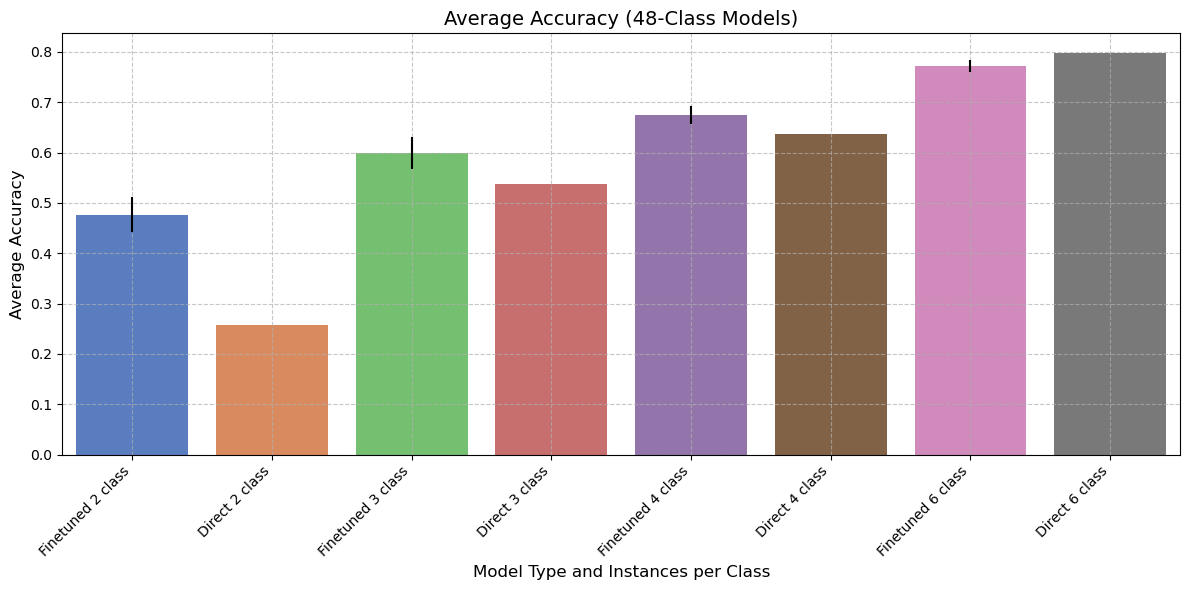

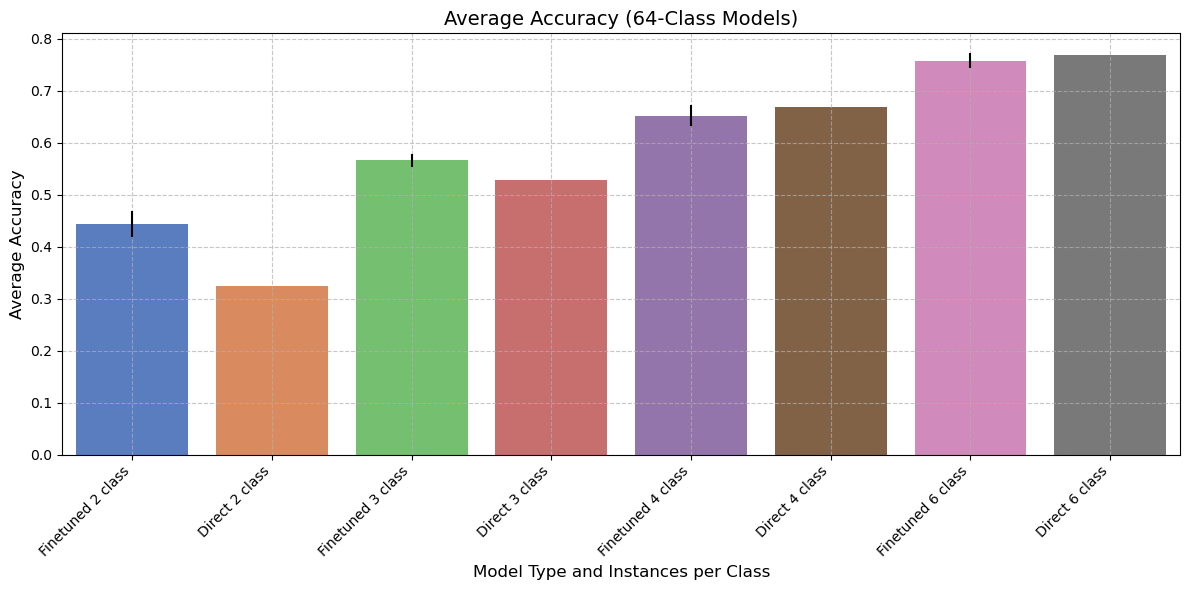

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure correct types
df['Model_Type'] = df['Model_Type'].astype(str).str.upper()
df['FT/T_Instance_per_class'] = pd.to_numeric(df['FT/T_Instance_per_class'], errors='coerce')

# Filter relevant rows
filtered_df = df[df['Model_Type'].isin(['FINETUNED', 'DIRECT'])]

# Loop for both class sizes
for cls_size in [48, 64]:
    # Filter for current class size
    class_df = filtered_df[filtered_df['FT/Direct_Classes'] == cls_size].copy()

    # Create Model_Group
    class_df['Model_Group'] = class_df.apply(
        lambda row: f"{row['Model_Type'].capitalize()} {int(row['FT/T_Instance_per_class'])} class",
        axis=1
    )

    # Group by Model_Group and calculate mean and std
    grouped = class_df.groupby('Model_Group')['Accuracy_Fixed_Testing_mean'].agg(['mean', 'std']).reset_index()

    # Define and apply order
    category_order = [
        'Finetuned 2 class', 'Direct 2 class',
        'Finetuned 3 class', 'Direct 3 class',
        'Finetuned 4 class', 'Direct 4 class',
        'Finetuned 6 class', 'Direct 6 class'
    ]
    grouped['Model_Group'] = pd.Categorical(grouped['Model_Group'], categories=category_order, ordered=True)
    grouped = grouped.sort_values('Model_Group')

    # Plot
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=grouped,
        x='Model_Group',
        y='mean',
        yerr=grouped['std'],  # Manually pass std for error bars
        capsize=0.1,
        palette='muted'
    )
    plt.title(f'Average Accuracy ({cls_size}-Class Models)', fontsize=14)
    plt.xlabel('Model Type and Instances per Class', fontsize=12)
    plt.ylabel('Average Accuracy', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


In [40]:
filtered_df.tail(12)

,Model,Accuracy,Accuracy_Fixed_Testing,F1,F1_Fixed_Testing,Epochs,Epochs_Fixed_Testing,Base_Model_Class,FT/Direct_Classes,FT/T_Instance_per_class,Model_Type,Overlapping,Accuracy_Fixed_Testing_mean,Accuracy_Fixed_Testing_std,F1_Fixed_Testing_mean,F1_Fixed_Testing_std,Epochs_Fixed_Testing_mean,Epochs_Fixed_Testing_std,Model_Group
59,120 Class ISL Base Model Finetuned with 48 Cla...,0.4611 (±0.0206),0.4732 (±0.0260),0.4484 (±0.0241),0.4594 (±0.0269),53.4000 (±8.5229),63.8000 (±10.3034),120.0,48.0,2.0,FINETUNED,No,0.4732,0.0260,0.4594,0.0269,63.8,10.3034,Finetuned 2 class
60,80 Class ISL Base Model Finetuned with 48 Clas...,0.5435 (±0.0109),0.5327 (±0.0204),0.5340 (±0.0109),0.5225 (±0.0250),85.6000 (±15.4997),76.0000 (±14.2548),80.0,48.0,2.0,FINETUNED,No,0.5327,0.0204,0.5225,0.0250,76.0,14.2548,Finetuned 2 class
61,80 Class ISL Base Model (Overlapping) Finetun...,0.4657 (±0.0206),0.4649 (±0.0256),0.4531 (±0.0218),0.4558 (±0.0254),78.8000 (±5.6356),90.4000 (±13.6176),80.0,48.0,2.0,FINETUNED,Yes,0.4649,0.0256,0.4558,0.0254,90.4,13.6176,Finetuned 2 class
62,80 Class ISL Base Model (Movement Overlapping...,NaN,0.4476 (±0.0429),NaN,0.4361 (±0.0498),NaN,87.6000 (±23.0963),80.0,48.0,2.0,FINETUNED,Movement,0.4476,0.0429,0.4361,0.0498,87.6,23.0963,Finetuned 2 class
63,64 Class SSL- 6 Instance Per Class (5 runs avg),0.7875 (±0.0218),0.7679 (±0.0156),0.7828 (±0.0240),0.7634 (±0.0148),169.8000 (±17.0106),152.6000 (±17.5909),NaN,64.0,6.0,DIRECT,NaN,0.7679,0.0156,0.7634,0.0148,152.6,17.5909,Direct 6 class
64,64 Class SSL- 4 Instance Per Class (5 runs avg),0.6691 (±0.0294),0.6687 (±0.0239),0.6621 (±0.0292),0.6636 (±0.0241),162.8000 (±9.5373),174.2000 (±15.0386),NaN,64.0,4.0,DIRECT,NaN,0.6687,0.0239,0.6636,0.0241,174.2,15.0386,Direct 4 class
65,64 Class SSL- 3 Instance Per Class (5 runs avg),0.5382 (±0.0293),0.5277 (±0.0238),0.5318 (±0.0298),0.5237 (±0.0213),199.2000 (±22.7807),185.8000 (±11.1068),NaN,64.0,3.0,DIRECT,NaN,0.5277,0.0238,0.5237,0.0213,185.8,11.1068,Direct 3 class
66,64 Class SSL- 2 Instance Per Class (5 runs avg),0.3160 (±0.0494),0.3241 (±0.0405),0.2937 (±0.0511),0.3166 (±0.0405),120.0000 (±17.8885),168.2000 (±21.8211),NaN,64.0,2.0,DIRECT,NaN,0.3241,0.0405,0.3166,0.0405,168.2,21.8211,Direct 2 class
67,48 Class SSL- 6 Instance Per Class (5 runs avg),0.7708 (±0.0275),0.7970 (±0.0167),0.7665 (±0.0277),0.7897 (±0.0166),153.0000 (±14.4637),155.6000 (±16.7404),NaN,48.0,6.0,DIRECT,NaN,0.7970,0.0167,0.7897,0.0166,155.6,16.7404,Direct 6 class
68,48 Class SSL- 4 Instance Per Class (5 runs avg),0.6276 (±0.0476),0.6369 (±0.0178),0.6234 (±0.0488),0.6322 (±0.0199),143.0000 (±23.2637),165.2000 (±16.2284),NaN,48.0,4.0,DIRECT,NaN,0.6369,0.0178,0.6322,0.0199,165.2,16.2284,Direct 4 class


/tmp/ipykernel_183441/2383001360.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Model_Group'] = filtered_df.apply(


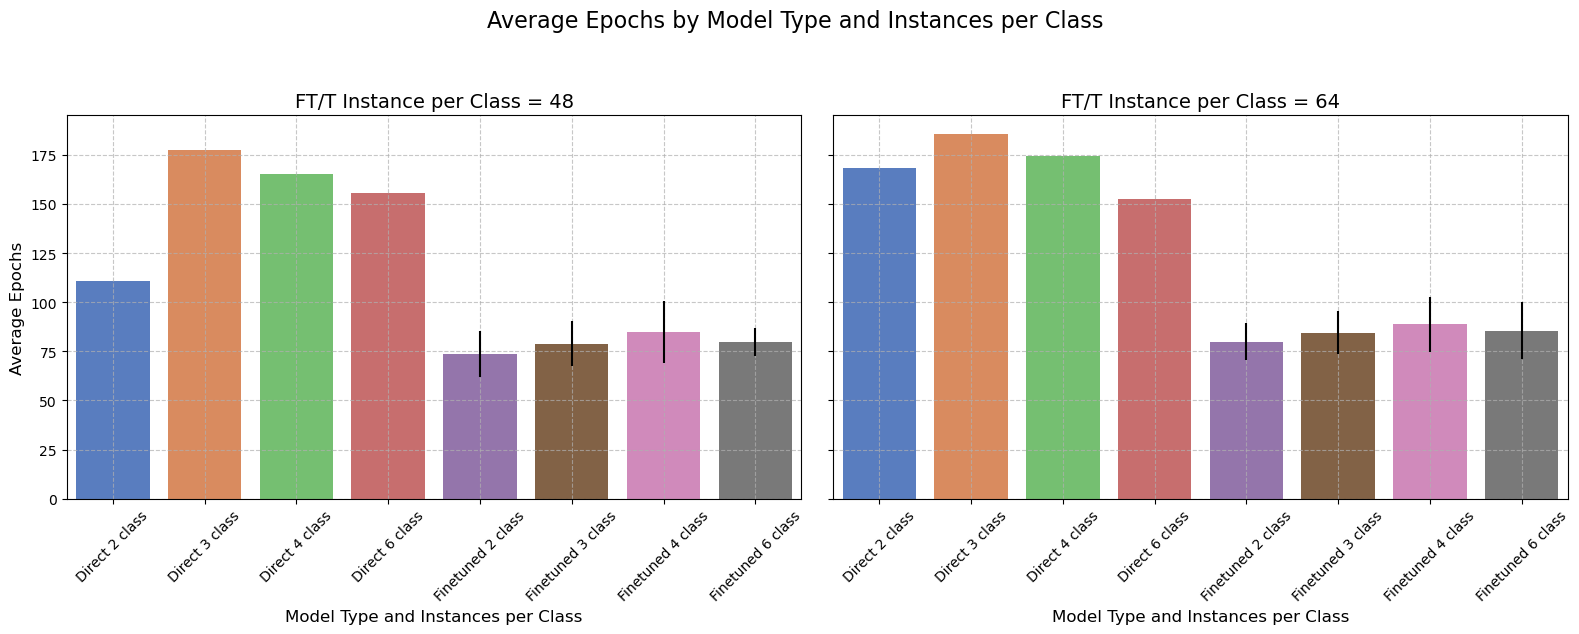

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure correct data types
df['Model_Type'] = df['Model_Type'].astype(str).str.upper()
df['FT/T_Instance_per_class'] = pd.to_numeric(df['FT/T_Instance_per_class'], errors='coerce')

# Filter relevant rows for finetuned and direct models
filtered_df = df[df['Model_Type'].isin(['FINETUNED', 'DIRECT'])]

# Create a new column for grouping
filtered_df['Model_Group'] = filtered_df.apply(
    lambda row: f"{row['Model_Type'].capitalize()} {int(row['FT/T_Instance_per_class'])} class",
    axis=1
)

# Define the order of the categories for the x-axis
category_order = [
    'Finetuned 2 class', 'Direct 2 class',
    'Finetuned 3 class', 'Direct 3 class',
    'Finetuned 4 class', 'Direct 4 class',
    'Finetuned 6 class', 'Direct 6 class'
]

# Split the data into two subsets based on FT/T_Instance_per_class (48 and 64)
df_48 = filtered_df[filtered_df['FT/Direct_Classes'] == 48]
df_64 = filtered_df[filtered_df['FT/Direct_Classes'] == 64]

grouped_48 = df_48.groupby('Model_Group')['Epochs_Fixed_Testing_mean'].agg(['mean', 'std']).reset_index()
grouped_64 = df_64.groupby('Model_Group')['Epochs_Fixed_Testing_mean'].agg(['mean', 'std']).reset_index()

# # For Direct models, manually fetch std from the original df_48
# for group in grouped_48['Model_Group']:
#     if group.startswith("Direct"):
#         std_value = df_48[df_48['Model_Group'] == group]['Epochs_Fixed_Testing_std'].values
#         if len(std_value) > 0:
#             grouped_48.loc[grouped_48['Model_Group'] == group, 'std'] = std_value[0]

# # Fill missing std values for Direct models using the original df_64
# for group in grouped_64['Model_Group']:
#     if group.startswith("Direct"):
#         std_value = df_64[df_64['Model_Group'] == group]['Epochs_Fixed_Testing_std'].values
#         if len(std_value) > 0:
#             grouped_64.loc[grouped_64['Model_Group'] == group, 'std'] = std_value[0]

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot for FT/T_Instance_per_class == 48
sns.barplot(
    data=grouped_48,
    x='Model_Group',
    y='mean',
    yerr=grouped_48['std'],
    capsize=0.1,
    palette='muted',
    ax=ax1
)
ax1.set_title('FT/T Instance per Class = 48', fontsize=14)
ax1.set_xlabel('Model Type and Instances per Class', fontsize=12)
ax1.set_ylabel('Average Epochs', fontsize=12)
ax1.tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability
ax1.grid(True, linestyle='--', alpha=0.7)  # Add a grid for readability

# Plot for FT/T_Instance_per_class == 64
sns.barplot(
    data=grouped_64,
    x='Model_Group',
    y='mean',
    yerr=grouped_64['std'],
    capsize=0.1,
    palette='muted',
    ax=ax2
)
ax2.set_title('FT/T Instance per Class = 64', fontsize=14)
ax2.set_xlabel('Model Type and Instances per Class', fontsize=12)
ax2.set_ylabel('')  # No y-label on the second plot since it's shared
ax2.tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability
ax2.grid(True, linestyle='--', alpha=0.7)  # Add a grid for readability

# Adjust layout to prevent overlap
plt.suptitle('Average Epochs by Model Type and Instances per Class', fontsize=16, y=1.05)
plt.tight_layout()

# Display the plot
plt.show()


In [50]:
# df_48

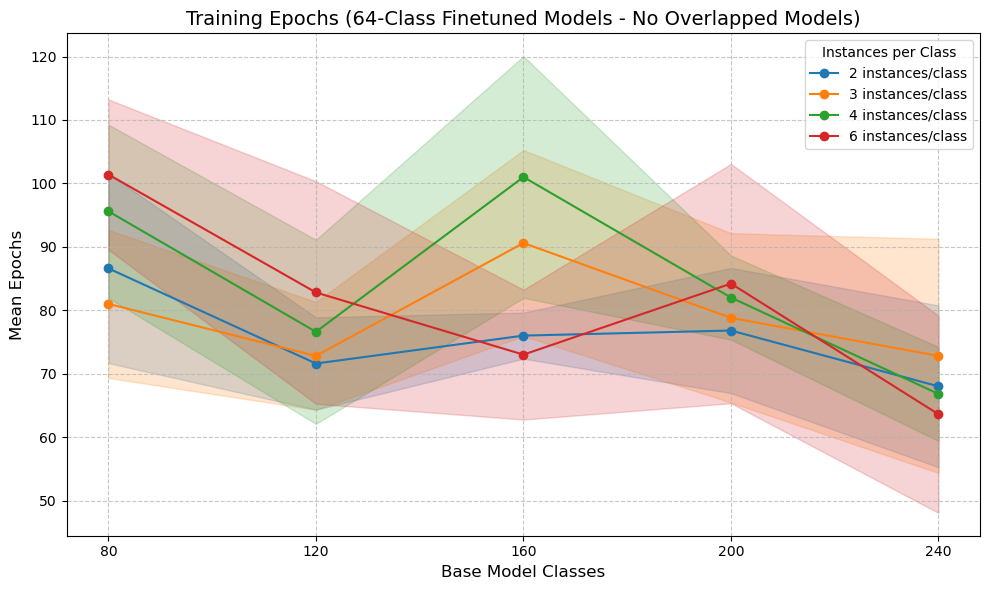

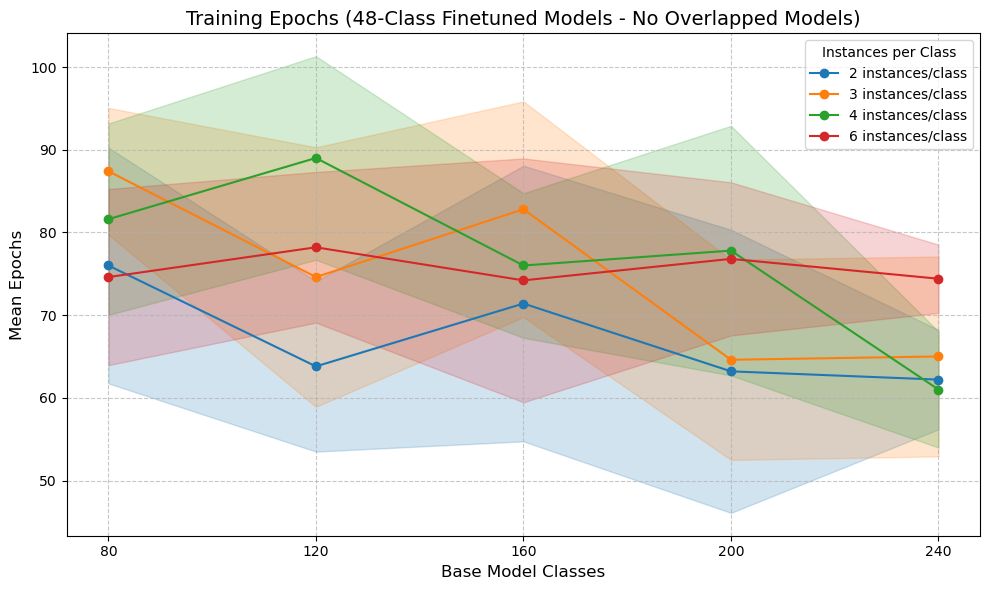

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for FINETUNED models with 64 FT/Direct_Classes
ft_data_64 = df[(df['Model_Type'] == 'FINETUNED') & (df['FT/Direct_Classes'] == 64) & (df['Overlapping'] == 'No')]

plt.figure(figsize=(10, 6))

# Choose a palette to stay consistent with the legend
palette = sns.color_palette('tab10')

# Plot each line and shaded area per group
for i, (key, group) in enumerate(ft_data_64.groupby('FT/T_Instance_per_class')):
    x = group['Base_Model_Class']
    y = group['Epochs_Fixed_Testing_mean']
    std = group['Epochs_Fixed_Testing_std']

    # Plot the line
    plt.plot(x, y, label=f'{int(key)} instances/class', marker='o', color=palette[i])

    # Plot the shaded area
    plt.fill_between(x, y - std, y + std, alpha=0.2, color=palette[i])

plt.title('Training Epochs (64-Class Finetuned Models - No Overlapped Models)', fontsize=14)
plt.xlabel('Base Model Classes', fontsize=12)
plt.ylabel('Mean Epochs', fontsize=12)
plt.xticks([80, 120, 160, 200, 240])  # Custom x-axis ticks
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Instances per Class', loc='upper right')
plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt
import seaborn as sns

# Filter for FINETUNED models with 64 FT/Direct_Classes
ft_data_48 = df[(df['Model_Type'] == 'FINETUNED') & (df['FT/Direct_Classes'] == 48) & (df['Overlapping'] == 'No')]

plt.figure(figsize=(10, 6))

# Choose a palette to stay consistent with the legend
palette = sns.color_palette('tab10')

# Plot each line and shaded area per group
for i, (key, group) in enumerate(ft_data_48.groupby('FT/T_Instance_per_class')):
    x = group['Base_Model_Class']
    y = group['Epochs_Fixed_Testing_mean']
    std = group['Epochs_Fixed_Testing_std']

    # Plot the line
    plt.plot(x, y, label=f'{int(key)} instances/class', marker='o', color=palette[i])

    # Plot the shaded area
    plt.fill_between(x, y - std, y + std, alpha=0.2, color=palette[i])

plt.title('Training Epochs (48-Class Finetuned Models - No Overlapped Models)', fontsize=14)
plt.xlabel('Base Model Classes', fontsize=12)
plt.ylabel('Mean Epochs', fontsize=12)
plt.xticks([80, 120, 160, 200, 240])  # Custom x-axis ticks
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Instances per Class', loc='upper right')
plt.tight_layout()
plt.show()


In [54]:
ft_data_64

,Model,Accuracy,Accuracy_Fixed_Testing,F1,F1_Fixed_Testing,Epochs,Epochs_Fixed_Testing,Base_Model_Class,FT/Direct_Classes,FT/T_Instance_per_class,Model_Type,Overlapping,Accuracy_Fixed_Testing_mean,Accuracy_Fixed_Testing_std,F1_Fixed_Testing_mean,F1_Fixed_Testing_std,Epochs_Fixed_Testing_mean,Epochs_Fixed_Testing_std
7,240 Class ISL Base Model Finetuned with 64 Cla...,0.7746 (±0.0129),0.7616 (±0.0188),0.7663 (±0.0167),0.7595 (±0.0216),83.8000 (±9.9880),63.6000 (±15.5512),240.0,64.0,6.0,FINETUNED,No,0.7616,0.0188,0.7595,0.0216,63.6,15.5512
8,200 Class ISL Base Model Finetuned with 64 Cla...,0.7272 (±0.0089),0.7670 (±0.0189),0.7213 (±0.0095),0.7595 (±0.0207),62.0000 (±7.6942),84.2000 (±18.8616),200.0,64.0,6.0,FINETUNED,No,0.7670,0.0189,0.7595,0.0207,84.2,18.8616
9,160 Class ISL Base Model Finetuned with 64 Cla...,0.7629 (±0.0310),0.7522 (±0.0224),0.7552 (±0.0326),0.7498 (±0.0215),75.4000 (±10.8922),73.0000 (±10.2372),160.0,64.0,6.0,FINETUNED,No,0.7522,0.0224,0.7498,0.0215,73.0,10.2372
10,120 Class ISL Base Model Finetuned with 64 Cla...,0.7067 (±0.0104),0.7429 (±0.0274),0.6972 (±0.0100),0.7408 (±0.0292),82.2000 (±12.3839),82.8000 (±17.5431),120.0,64.0,6.0,FINETUNED,No,0.7429,0.0274,0.7408,0.0292,82.8,17.5431
11,80 Class ISL Base Model Finetuned with 64 Clas...,0.7679 (±0.0149),0.7830 (±0.0134),0.7640 (±0.0150),0.7739 (±0.0172),104.6000 (±14.1789),101.4000 (±11.8423),80.0,64.0,6.0,FINETUNED,No,0.7830,0.0134,0.7739,0.0172,101.4,11.8423
12,80 Class ISL Base Model (Overlapping) Finetun...,0.7286 (±0.0237),0.7536 (±0.0128),0.7201 (±0.0244),0.7465 (±0.0125),100.6000 (±13.5735),103.2000 (±4.8744),80.0,64.0,6.0,FINETUNED,Yes,0.7536,0.0128,0.7465,0.0125,103.2,4.8744
13,80 Class ISL Base Model (Movement Overlapping...,NaN,0.7455 (±0.0180),NaN,0.7421 (±0.0195),NaN,90.4000 (±9.1345),80.0,64.0,6.0,FINETUNED,Movement,0.7455,0.0180,0.7421,0.0195,90.4,9.1345
14,240 Class ISL Base Model Finetuned with 64 Cla...,0.6457 (±0.0205),0.6612 (±0.0296),0.6401 (±0.0200),0.6484 (±0.0284),74.0000 (±11.0272),66.8000 (±7.4135),240.0,64.0,4.0,FINETUNED,No,0.6612,0.0296,0.6484,0.0284,66.8,7.4135
15,200 Class ISL Base Model Finetuned with 64 Cla...,0.6242 (±0.0285),0.6536 (±0.0273),0.6185 (±0.0279),0.6447 (±0.0272),73.2000 (±10.1666),82.0000 (±6.6332),200.0,64.0,4.0,FINETUNED,No,0.6536,0.0273,0.6447,0.0272,82.0,6.6332
16,160 Class ISL Base Model Finetuned with 64 Cla...,0.6832 (±0.0251),0.6674 (±0.0123),0.6836 (±0.0233),0.6572 (±0.0113),90.6000 (±16.8950),101.0000 (±19.0578),160.0,64.0,4.0,FINETUNED,No,0.6674,0.0123,0.6572,0.0113,101.0,19.0578
